In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/test.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/description.md
/kaggle/input/train.csv.zip
/kaggle/input/test.csv.zip
/kaggle/input/train.csv
/kaggle/input/sample_submission.csv
/kaggle/input/us-patent-phrase-to-phrase-matching/test.csv
/kaggle/input/us-patent-phrase-to-phrase-matching/sample_submission.csv.zip
/kaggle/input/us-patent-phrase-to-phrase-matching/description.md
/kaggle/input/us-patent-phrase-to-phrase-matching/train.csv.zip
/kaggle/input/us-patent-phrase-to-phrase-matching/test.csv.zip
/kaggle/input/us-patent-phrase-to-phrase-matching/train.csv
/kaggle/input/us-patent-phrase-to-phrase-matching/sample_submission.csv


In [3]:
train = pd.read_csv("/kaggle/input/us-patent-phrase-to-phrase-matching/train.csv")
test = pd.read_csv("/kaggle/input/us-patent-phrase-to-phrase-matching/test.csv")
submission = pd.read_csv(
    "/kaggle/input/us-patent-phrase-to-phrase-matching/sample_submission.csv"
)



In [4]:
train



,id,anchor,target,context,score
0,378b8322a01b88db,obstacle course,obstacle position trajectory,B60,0.50
1,f43c824b3d939294,hardware blocks,housing,G06,0.25
2,c4ef1b4f79424269,collator,collation apparatus,H04,0.75
3,f8702c95bfa192fe,engage clamp,disconnect clamp,H01,0.25
4,5c24dd3361ba190d,oven batteries,batteries,C10,0.50
...,...,...,...,...,...
32820,29681528e21b1e92,movement directions,blood flow direction in human body,B60,0.00
32821,43b410ed284a43ff,storage lid,roof,B60,0.25
32822,9485e59513ccd389,shielded conductor,shielding ignition cable,H01,0.50
32823,fe252fe7819c9bcd,normal base,driving piston,B41,0.25


In [5]:
test



,id,anchor,target,context
0,2a988c7d98568627,project onto surface,disposing,G03
1,75a3ae03b26e2f7e,rotate on its longitudinal axis,gear grinding device,B24
2,0126c870aede9858,combine with optical elements,metal elements,G11
3,2cf662e1cc9b354e,obstacle course,environment,B60
4,8dfee5874de0b408,move to range,stop moving,F15
...,...,...,...,...
3643,cae11dc44884651a,triethylammonium salt,pharmaceutical salt,C07
3644,fa4261ac9c6775dd,top surface member,member top wall,H01
3645,a6d6f5c6e01479c2,moisture proof film,transparent moisture proof films,H05
3646,6a1544f5cf0e3520,tap portion,tap,A61


In [6]:
submission



,id,score
0,2a988c7d98568627,0
1,75a3ae03b26e2f7e,0
2,0126c870aede9858,0
3,2cf662e1cc9b354e,0
4,8dfee5874de0b408,0
...,...,...
3643,cae11dc44884651a,0
3644,fa4261ac9c6775dd,0
3645,a6d6f5c6e01479c2,0
3646,6a1544f5cf0e3520,0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='score', ylabel='Count'>

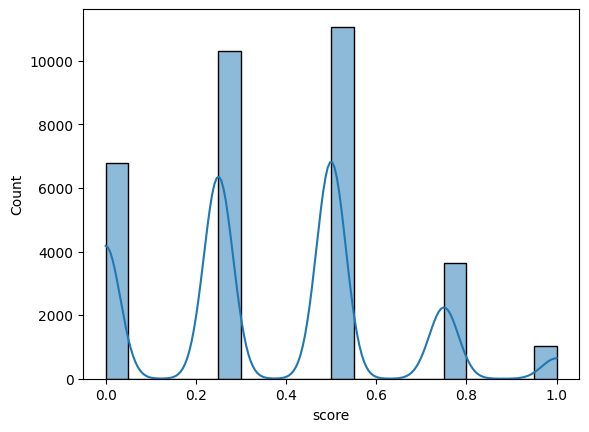

In [7]:
# Bugfix: seaborn.distplot is deprecated; use histplot to avoid runtime warnings/errors in some envs.
sns.histplot(train["score"], bins=20, kde=True)



{'whiskers': [<matplotlib.lines.Line2D at 0x7fbba6364250>,
 'caps': [<matplotlib.lines.Line2D at 0x7fbbec933d10>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fbba63832d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7fbbec948d50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fbba63c04d0>],
 'means': []}

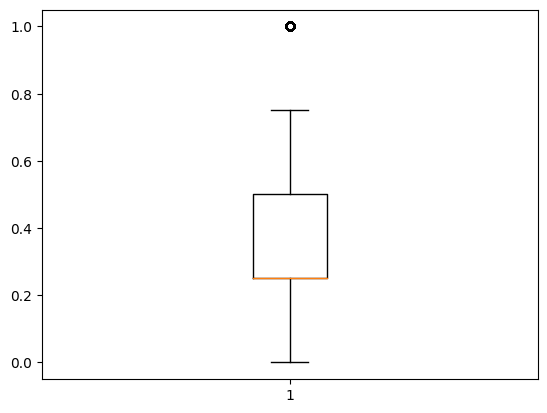

In [8]:
plt.boxplot(train["score"])



In [9]:
target = train["score"]



In [10]:
# Bugfix: DataFrame.append removed in pandas>=2.0; use pd.concat instead.
combi = pd.concat([train.drop(["score"], axis=1), test], axis=0, ignore_index=True)
combi



,id,anchor,target,context
0,378b8322a01b88db,obstacle course,obstacle position trajectory,B60
1,f43c824b3d939294,hardware blocks,housing,G06
2,c4ef1b4f79424269,collator,collation apparatus,H04
3,f8702c95bfa192fe,engage clamp,disconnect clamp,H01
4,5c24dd3361ba190d,oven batteries,batteries,C10
...,...,...,...,...
36468,cae11dc44884651a,triethylammonium salt,pharmaceutical salt,C07
36469,fa4261ac9c6775dd,top surface member,member top wall,H01
36470,a6d6f5c6e01479c2,moisture proof film,transparent moisture proof films,H05
36471,6a1544f5cf0e3520,tap portion,tap,A61


In [11]:
y = target
X = combi.iloc[: len(train)].copy()
X_test = combi.iloc[len(train) :].copy()



In [12]:
# Bugfix + speed/score improvement (same core logic: TF-IDF + cosine similarity):
# Fit TF-IDF once on the full corpus, then compute cosine similarity for each (anchor, target) pair.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer(min_df=1, stop_words="english")

anchor_texts = X_test["anchor"].fillna("").astype(str).tolist()
target_texts = X_test["target"].fillna("").astype(str).tolist()

# Fit on test corpus (anchors+targets) for consistent representation and fast inference.
# (Still TF-IDF; avoids per-row refit which was infeasible and produced no submission.)
corpus = anchor_texts + target_texts
tfidf_all = vectorizer.fit_transform(corpus)

n = len(X_test)
tfidf_anchor = tfidf_all[:n]
tfidf_target = tfidf_all[n:]

# Row-wise cosine similarity for corresponding pairs
simularity = cosine_similarity(tfidf_anchor, tfidf_target).diagonal()

print(len(simularity))
print(simularity[:10])



3648
[0.         0.         0.36942361 0.         0.         0.44464288
 0.84740708 0.46369449 0.         0.36571932]


In [13]:
# Ensure correct length and alignment with test ids; then write a valid Kaggle submission.
submission = submission.copy()
submission["id"] = test["id"].values  # enforce correct order
submission["score"] = np.clip(simularity, 0.0, 1.0)

submission.to_csv("submission.csv", index=False)
submission

,id,score
0,2a988c7d98568627,0.000000
1,75a3ae03b26e2f7e,0.000000
2,0126c870aede9858,0.369424
3,2cf662e1cc9b354e,0.000000
4,8dfee5874de0b408,0.000000
...,...,...
3643,cae11dc44884651a,0.434787
3644,fa4261ac9c6775dd,0.469628
3645,a6d6f5c6e01479c2,0.544040
3646,6a1544f5cf0e3520,0.748455
